# Dependencias y constantes

In [72]:
# Import de librerías importantes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd
import itertools as it

# Librerías utilizadas en algunos análisis
from scipy.stats import linregress                  # Para el análisis de regresión lineal
from scipy.stats import friedmanchisquare, f_oneway # Para el test Friedman y ANOVA
from scipy.stats import wilcoxon                    # Para el test de Wilcoxon     
from sklearn.linear_model import LinearRegression   # Para la regresión lineal múltiple
from sklearn import tree                            # Para la creación de árboles de decisión
from sklearn.ensemble import RandomForestRegressor  # Para la creación de bosques aleatorios (random forest)


# Para poder cargar los módulos escritos en la raíz del proyecto
from pathlib import Path
import sys

RAIZ_PROYECTO = Path().resolve().parent
sys.path.insert(0, str(RAIZ_PROYECTO))

import src.estadistica as est
import src.representacion as rep
import src.utils as ut

# Para poder recargar los módulos sin tener que reiniciar el kernel
import importlib
importlib.reload(est)
importlib.reload(rep)
importlib.reload(ut)

R_DATAFRAME = "../datos/out/df_long.csv"            # Ruta del dataframe en csv
DIR_SALIDA = "../salida/estudio_disposiciones/"     # Directorio de salida de los resultados

SEMILLA = 1905                                      # Semilla para la generación de números aleatorios
COLUMNA_P = "Pdc"                                   # Nombre de la columna que contiene los valores de potencia

In [73]:
# Funciones muy utilizadas en el cuaderno
def dataframe():
    """Función para cargar el dataframe desde el csv y convertir la columna Datetime a formato datetime."""
    df = pd.read_csv(R_DATAFRAME, parse_dates=['Datetime'])
    return df

# Cuaderno de estudio de configuración de placas

Este cuaderno Jupyter busca comprobar el peso de distintas configuraciones en la disposición de las placas respecto a la potencia que son capaces de generar.

## Comprobación del impacto de la configuración

Uno de los objetivos de este estudio es comprobar si la configuración de las placas tienen un impacto significativo en la potencia generada. Para comprobarlo, se compararán distintas configuraciones y se analizarán los resultados obtenidos.

### Impacto de la posición de las placas

En la planta experimental se encuentran tres posiciones en las que las placas se pueden encontrar instaladas:
1. La izquierda (al este) del grupo.
2. La derecha (al oeste) del grupo.
3. En el centro del grupo.

Esta sección buscará la importancia de la posición de las placas comparando los resultados obtenidos en cada una de las posiciones.

 - P-valor izquierda: 0.01
 - P-valor derecha: 0.01
 - P-valor centro: 0.01
Las series no siguen distribución normal
Resultados del test:
 - Estadístico: 94140.80948261349
 - P-valor: 0.0
Las series son estadísticamente diferentes


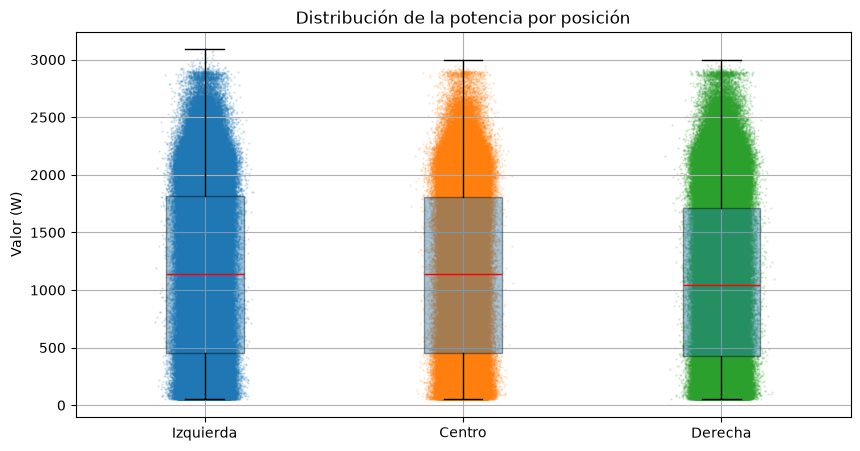

In [3]:
df = dataframe()

# Hago tres columnas nuevas para poder filtrar por posición de las placas
df_izq = df[df["Disp_Izq"] == 1]
df_der = df[df["Disp_Der"] == 1]
df_cent = df[df["Disp_Cent"] == 1]

# Aplico un test de normalidad a cada una de las columnas de interés para ver si se puede aplicar un test anova para comprobar 
# si las series son estadísticamente diferentes.
p_valor_izq = est.test_normalidad(df_izq[COLUMNA_P]).get("pvalor")
p_valor_der = est.test_normalidad(df_der[COLUMNA_P]).get("pvalor")
p_valor_cent = est.test_normalidad(df_cent[COLUMNA_P]).get("pvalor")

print(f" - P-valor izquierda: {p_valor_izq}")
print(f" - P-valor derecha: {p_valor_der}")
print(f" - P-valor centro: {p_valor_cent}")

# Si todos los p-valores son mayores a 0.05 las series son normales
normales = False
if p_valor_izq > 0.05 and p_valor_der > 0.05 and p_valor_cent > 0.05:
    normales = True

print("Las series siguen distribución normal" if normales else "Las series no siguen distribución normal")

# Unifico las series en un solo dataframe para poder aplicar el test de Friedman o ANOVA con arrays de la misma longitud
df_unido = pd.merge(df_izq[["Datetime", COLUMNA_P]], df_der[["Datetime", COLUMNA_P]], on="Datetime", suffixes=("_izq", "_der"))
df_unido = pd.merge(df_unido, df_cent[["Datetime", COLUMNA_P]], on="Datetime")
df_unido = df_unido.rename(columns={COLUMNA_P: f"{COLUMNA_P}_cent"})

df_unido = df_unido.dropna(subset=[f"{COLUMNA_P}_izq", f"{COLUMNA_P}_der", f"{COLUMNA_P}_cent"])
                                        
if not normales:
    # Si las series no son normales, aplico Friedman para ver si son estadísticamente diferentes
    estadistico, p_valor = friedmanchisquare(df_unido[f"{COLUMNA_P}_izq"], df_unido[f"{COLUMNA_P}_der"], df_unido[f"{COLUMNA_P}_cent"])
else:
    # Si lo son, uso anova
    estadistico, p_valor = f_oneway(df_unido[f"{COLUMNA_P}_izq"], df_unido[f"{COLUMNA_P}_der"], df_unido[f"{COLUMNA_P}_cent"])

print(f"Resultados del test:\n - Estadístico: {estadistico}\n - P-valor: {p_valor}")

if p_valor < 0.05:
    print("Las series son estadísticamente diferentes")
else:
    print("Las series no son estadísticamente diferentes")
    
rep.mostrar_boxplot([df_izq[COLUMNA_P], df_cent[COLUMNA_P], df_der[COLUMNA_P]],
                titulos=["Izquierda", "Centro", "Derecha"],
                titulo_figura="Distribución de la potencia por posición",
                u_medida="W")

In [ ]:
df = dataframe()

# Hago tres columnas nuevas para poder filtrar por posición de las placas
df_izq = df[df["Disp_Izq"] == 1]
df_der = df[df["Disp_Der"] == 1]
df_cent = df[df["Disp_Cent"] == 1]

df_izq.name = "Izquierda"
df_der.name = "Derecha"
df_cent.name = "Centro"

dataframes = [df_izq, df_cent, df_der]


# Hago un producto cartesiano de las tres series para compararlas dos a dos
pruebas = list(it.product(dataframes, repeat=2))

tabla_diferencias = pd.DataFrame(
    {"Serie" : ["Izquierda", "Centro", "Derecha"],
     "Izquierda": [0, None, None],
      "Centro": [None, 0, None],
      "Derecha": [None, None, 0]}
)
tabla_diferencias.set_index("Serie", inplace=True)

for (serie1, serie2) in pruebas:
    if serie1.name != serie2.name:
        # Uno los dataframes según la hora de la lectura para que tengan el mismo tamaño y poder aplicar el test de Wilcoxon
        df_unido = pd.merge(serie1, serie2, on="Datetime", suffixes=('_' + serie1.name, '_' + serie2.name))
        
        mbe = est.mbe(df_unido[f"{COLUMNA_P}_{serie1.name}"], df_unido[f"{COLUMNA_P}_{serie2.name}"])
        tabla_diferencias.loc[serie1.name, serie2.name] = mbe
        
print("Tabla de diferencias de potencia entre las posiciones de las placas (en W):")
print(tabla_diferencias)

# Guardo la tabla de diferencias como fichero latex en salida para la memoria
tabla_diferencias.to_latex(f"{DIR_SALIDA}/posicion_en_grupo/tabla_diferencias.tex", float_format="%.2f", caption="Diferencias de potencia entre las posiciones de las placas (en W)", label="tab:diferencias_placas_pos_en_grupo")

Tabla de diferencias de potencia entre las posiciones de las placas (en W):
           Izquierda     Centro    Derecha
Serie                                     
Izquierda   0.000000   1.293790  65.411313
Centro     -1.293790   0.000000  64.060191
Derecha   -65.411313 -64.060191   0.000000


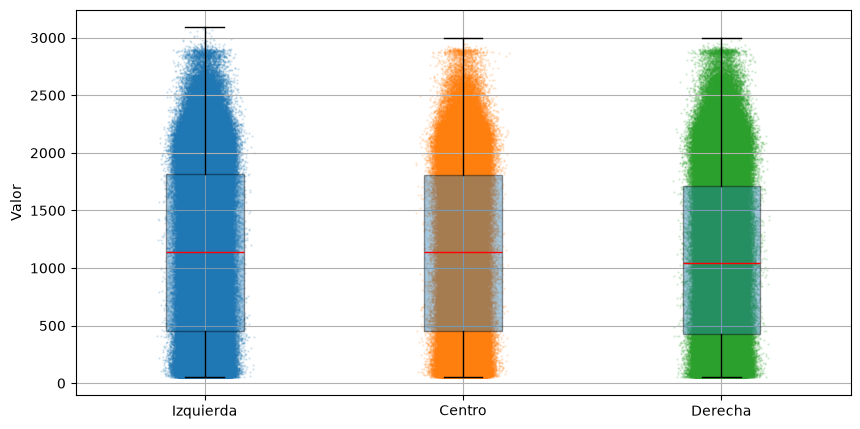

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Izquierda': 0.01, 'Centro': 0.01, 'Derecha': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 94140.80948.
- La tabla de diferencias (MBE) entre las series es:
           Izquierda     Centro    Derecha
Serie                                     
Izquierda   0.000000   1.293790  65.411313
Centro     -1.293790   0.000000  64.060191
Derecha   -65.411313 -64.060191   0.000000


In [71]:
df = dataframe()
_, _, _, _, _, tabla = est.interpretar_diferencias_series(*est.evaluar_diferencias_series(df, variable=COLUMNA_P, nombres_series=["Izquierda", "Centro", "Derecha"], variables_ficticias=["Disp_Izq", "Disp_Cent", "Disp_Der"]))
ut.guardar_tabla_latex(tabla, f"{DIR_SALIDA}/posicion_en_grupo/tabla_diferencias_posiciones.tex", "Diferencias de potencia entre las posiciones de las placas (en W)", "tab:diferencias_placas_pos_en_grupo")

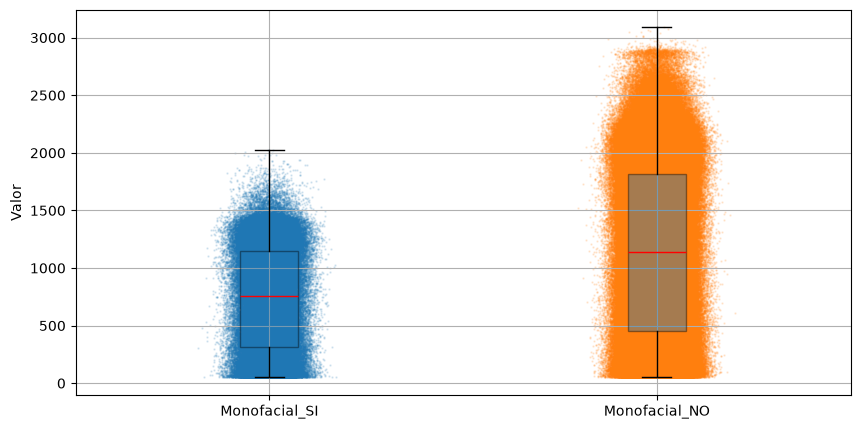

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Monofacial_SI': 0.01, 'Monofacial_NO': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 550753523.50000.
- La tabla de diferencias (MBE) entre las series es:
               Monofacial_SI  Monofacial_NO
Serie                                      
Monofacial_SI       0.000000    -454.151044
Monofacial_NO     454.151044       0.000000


In [70]:
df = dataframe()
_, _, _, _, _, tabla = est.interpretar_diferencias_series(*est.evaluar_diferencia_variable_on_off(df, variable=COLUMNA_P, variable_ficticia="Monofacial", nombre_serie="Monofacial"))
ut.guardar_tabla_latex(tabla, f"{DIR_SALIDA}/monofacial/tabla_diferencias_monofacial.tex", "Diferencias de potencia entre las placas monofaciales y bifaciales (en W)", "tab:diferencias_placas_monofaciales")

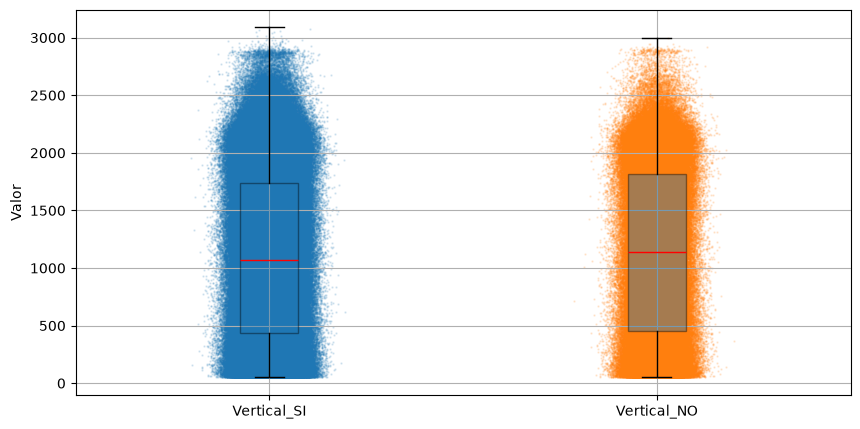

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Vertical_SI': 0.01, 'Vertical_NO': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 2555607315791.50000.
- La tabla de diferencias (MBE) entre las series es:
             Vertical_SI  Vertical_NO
Serie                                
Vertical_SI     0.000000   -51.694862
Vertical_NO    51.694862     0.000000


In [74]:
df = dataframe()
_, _, _, _, _, tabla = est.interpretar_diferencias_series(*est.evaluar_diferencia_variable_on_off(df, variable=COLUMNA_P, variable_ficticia="Disp_Vert", nombre_serie="Vertical"))
ut.guardar_tabla_latex(tabla, f"{DIR_SALIDA}/vertical/tabla_diferencias_vertical.tex", "Diferencias de potencia entre las placas verticales y horizontales (en W)", "tab:diferencias_placas_vertical")